# Week 1 Assignment: Visualization & Foundations
**DSE6230: Forecasting Methods and Applications**

In this assignment, you will get familiar with `pandas` time series and basic plotting.

In [3]:
!pip install pandas numpy matplotlib scikit-learn statsmodels

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utilsforecast.plotting import plot_series
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Part 1: Self-Guided Exercises

### Exercise 1.1: Date Ranges
**Instruction**: Create a pandas Series named `dates` containing a date range from '2023-01-01' to '2023-01-10' (inclusive).

In [ ]:
# Code Here
dates = pd.Series(pd.date_range(start='2023-01-01', end='2023-01-10'))

In [ ]:
#| Check your work
try:
    assert 'dates' in locals(), "Variable 'dates' not defined."
    assert isinstance(dates, pd.DatetimeIndex) or pd.api.types.is_datetime64_any_dtype(dates), "Should be overlapping dates."
    assert len(dates) == 10, "Should have 10 days."
    print("Exercise 1.1 Passed!")
except AssertionError as e:
    print(f"Exercise 1.1 Failed: {e}")
except Exception as e:
    print(f"Error: {e}")

Exercise 1.1 Passed!


### Exercise 1.2: Creating a Time Series
**Instruction**: Create a DataFrame `df` with the `dates` from 1.1 as the index and a column `sales` with random values (use `np.random.rand`).

In [ ]:
# Your Code Here
df = pd.DataFrame(np.random.rand(10), index=dates, columns=['sales'])
print(df)

               sales
2023-01-01  0.022331
2023-01-02  0.873838
2023-01-03  0.320035
2023-01-04  0.201028
2023-01-05  0.709816
2023-01-06  0.133200
2023-01-07  0.540021
2023-01-08  0.968373
2023-01-09  0.638509
2023-01-10  0.010775


In [ ]:
#| Check your work
try:
    assert 'df' in locals(), "DataFrame 'df' missing."
    assert isinstance(df.index, pd.DatetimeIndex), "Index must be a DatetimeIndex."
    assert 'sales' in df.columns, "Column 'sales' missing."
    print("Exercise 1.2 Passed!")
except AssertionError as e:
    print(f"Exercise 1.2 Failed: {e}")

Exercise 1.2 Passed!


### Exercise 1.3: Simple Plotting
**Instruction**: Plot the `sales` column. Assign the plot axes object to a variable named `ax`.

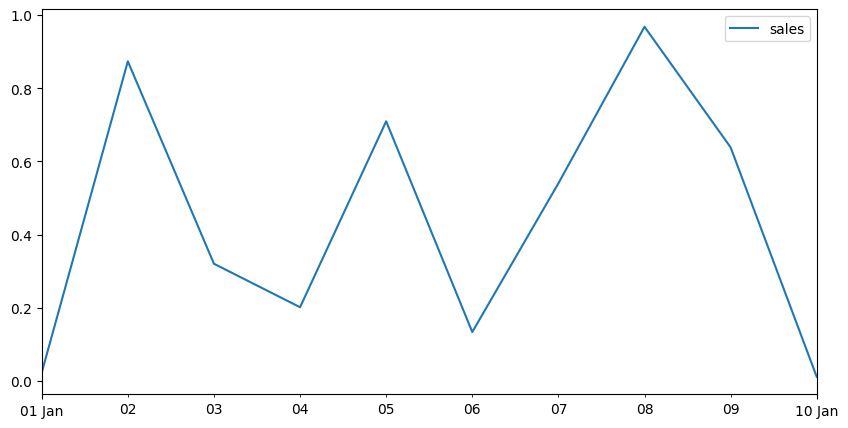

In [ ]:
# Your Code Here
ax = df.plot(y='sales', figsize=(10, 5))
#

### Exercise 1.4: Computing MAE and RMSE
**Instruction**: Given `truth` and `forecast` arrays, compute MAE and RMSE.

In [ ]:
truth = np.array([100, 102, 98, 105])
forecast = np.array([101, 100, 100, 100])
# Your Code Here
# mae = ...
# rmse = ...
def mae(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return np.mean(np.abs(y - yhat))

def rmse(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return np.sqrt(np.mean((y - yhat) ** 2))

mae(truth, forecast)
rmse(truth, forecast)

np.float64(2.9154759474226504)

In [ ]:
#| Check your work
try:
    assert 'mae' in locals(), "Variable 'mae' missing."
    print("Exercise 1.4 Passed!")
except Exception as e:
    print(f"Exercise 1.4 Failed: {e}")

Exercise 1.4 Passed!


## Part 2: Textbook Exercises

Complete the following exercises from *Forecasting: Principles and Practice, the Pythonic Way*.

### Chapter 1: Getting Started

#### Question 1.1
> For cases 3 and 4 in Section 1.5, list the possible predictor variables that might be useful, assuming that the relevant data are available.

#### Question 1.2
> For case 3 in Section 1.5, describe the five steps of forecasting in the context of this project.

### Chapter 2: Time Series Graphics

#### Question 2.1
> Explore the following four time series: `Bricks` from `aus_production`, `Lynx` from `pelt`, `GOOG_Close` from `gafa_stock`, `Demand` from `vic_elec`.
> - Use `info()` to find out about the data in each series.
> - What is the time interval of each series?
> - Use `plot_series()` to produce a time plot of each series.
> - For the last plot, modify the axis labels and title.

#### Question 2.2
> Use `query()` to find what days corresponded to the peak closing price for each of the four stocks in `gafa_stock`.

#### Question 2.3
> Download `tute1.csv`, read it into Python, and convert it to time series. Construct time series plots of each of the three series (Sales, AdBudget, GDP).

#### Question 2.4
> Download `us_total.csv`. Create a dataframe with year as the index. Plot the annual natural gas consumption by state for the New England area.

#### Question 2.5
> Download `tourism.xlsx`. Find what combination of Region and Purpose had the maximum number of overnight trips on average. Create a new dataframe which combines the Purposes and Regions, and just has total trips by State.

#### Question 2.6
> Use `plot_series()` to visualize the `aus_arrivals` data. Use seasonal and subseries plots to compare arrivals from Japan, NZ, UK, and US.

#### Question 2.7
> Select a random series from `aus_retail`. Explore it using `plot_series()`, `seasonal_decompose()`, `lag_plot()`, and `plot_acf()`. Can you spot seasonality, cyclicity, or trend?

#### Question 2.8
> Use `plot_series()`, `seasonal_decompose()`, `lag_plot()`, and `plot_acf()` to explore: "Total Private" Employed from `us_employment`, `Bricks` from `aus_production`, `Hare` from `pelt`, "H02" Cost from `PBS`, and `Barrels` from `us_gasoline`.

#### Question 2.9
> Extract pig slaughters in Victoria between 1990 and 1995 from `aus_livestock`. Plot the series and ACF. How do they differ from white noise?

#### Question 2.10
> Compute the daily changes in Google closing stock prices (`dgoog`). Plot the differences and their ACF. Do they look like white noise?

In [ ]:
# Your Code Here

Question 1.1:

For Case 3 some relevant predictor variables are current vehicle value, previous vehicle values (yearly), strenght of economy, average price of gas per gallon, fuel economy.
For Case 4 some relevant predictors would be time of day, day of week, month, passenger class (economy, business, first), plane route.

Question 1.2:

Step 1: Problem definition

Understanding how resale forecasts will be used — to inform leasing and sales policies aimed at maximizing profit.

Step 2: Gathering information

Pulling together data from the company's historical customers and leases.

Step 3: Preliminary analysis

Graph resale values against variables like age, mileage, and vehicle type. Look for trends, seasonality, and the strength of relationships between resale value and potential predictors.

Step 4: Choosing and fitting models

Based on the data available and the relationships found, compare candidate models to forecast resale value, selecting based on how well the model fits and how the forecasts will be used.

Step 5: Using and evaluating the model

Apply the model to forecast resale values for current fleet vehicles; assess accuracy once actual sale prices come in.

In [35]:
# Question 2.1
!pip install utilsforecast
from utilsforecast.plotting import plot_series
import pandas as pd

aus_production = pd.read_csv('/content/aus_production_formatted.csv', parse_dates=['ds'])
pelt = pd.read_csv('/content/pelt.csv', parse_dates=['ds'])
gafa_stock = pd.read_csv('/content/gafa_stock.csv', parse_dates=['ds'])
vic_elec = pd.read_csv('/content/vic_elec.csv', parse_dates=['ds'])

bricks = aus_production.loc[lambda x: x['unique_id'] == 'Bricks']
lynx = pelt.loc[lambda x: x['unique_id'] == 'lynx']
goog_close = gafa_stock.loc[lambda x: x['unique_id'] == 'GOOG_Close']
demand = vic_elec.loc[lambda x: x['unique_id'] == 'Demand']

bricks.info()
lynx.info()
goog_close.info()
demand.info()

<class 'pandas.core.frame.DataFrame'>
Index: 218 entries, 436 to 653
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  218 non-null    object        
 1   ds         218 non-null    datetime64[ns]
 2   y          198 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 6.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 91 entries, 91 to 181
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  91 non-null     object        
 1   ds         91 non-null     datetime64[ns]
 2   y          91 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 18870 to 20127
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----

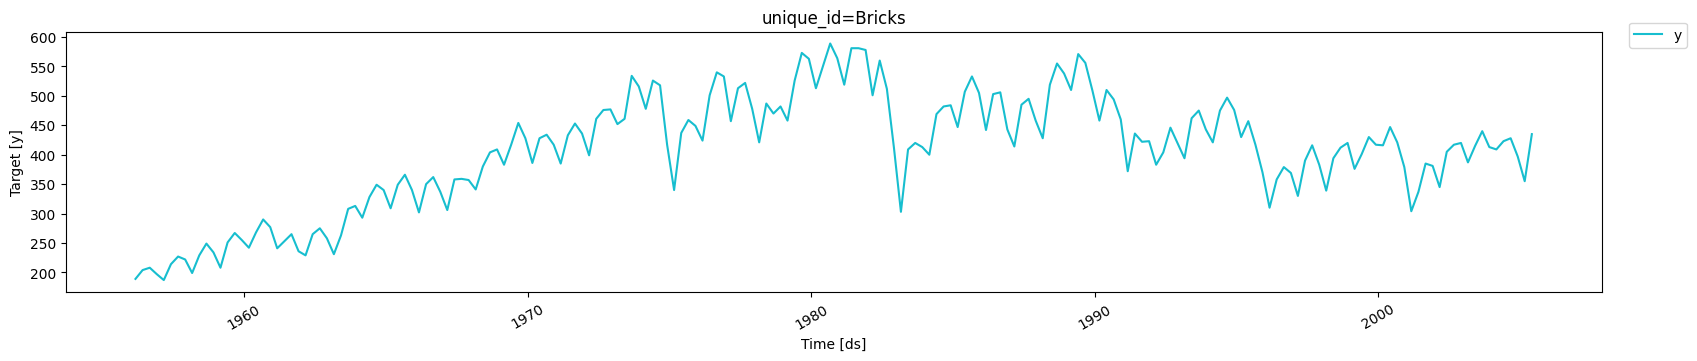

In [39]:
plot_series(bricks, id_col="unique_id", time_col="ds", target_col="y")

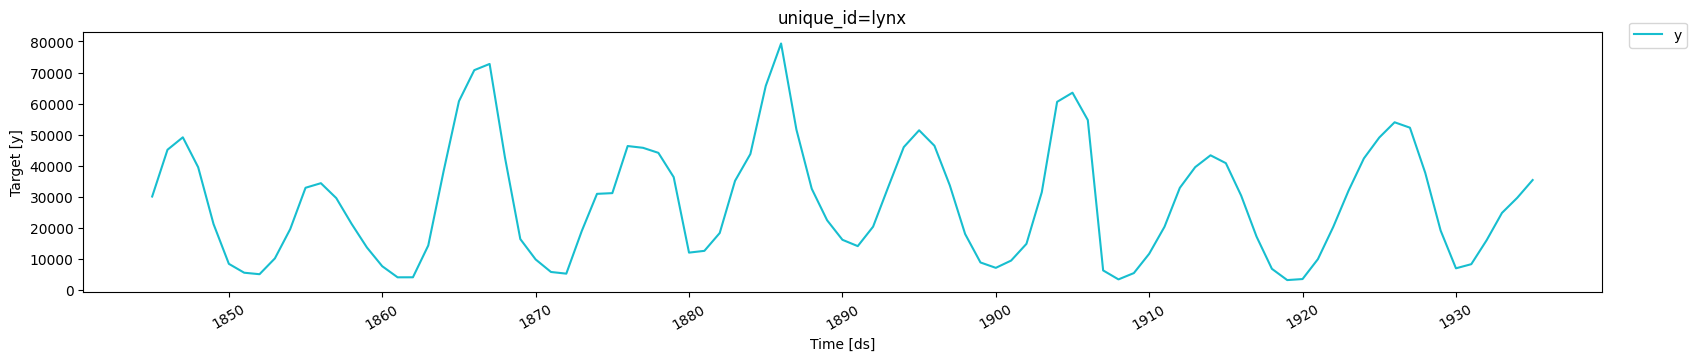

In [40]:
plot_series(lynx, id_col="unique_id", time_col="ds", target_col="y")

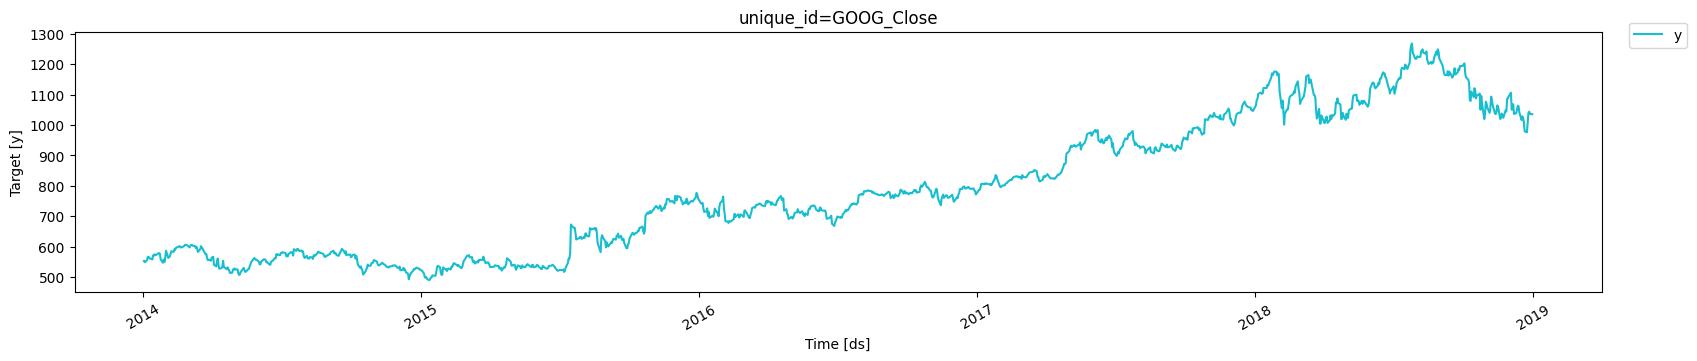

In [41]:
plot_series(goog_close, id_col="unique_id", time_col="ds", target_col="y")

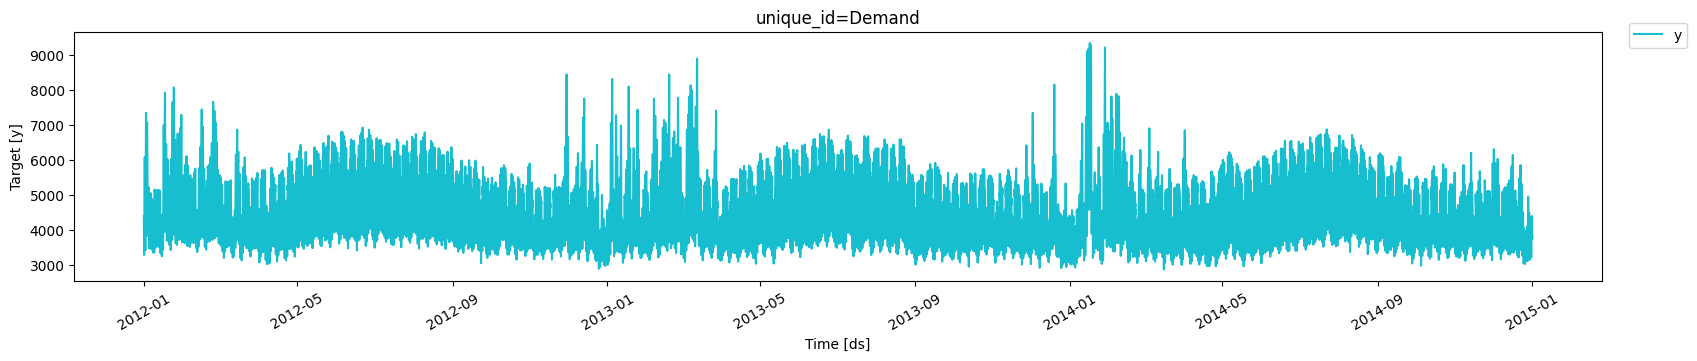

In [46]:
plot_series(
    demand, id_col="unique_id", time_col="ds", target_col="y")

In [47]:
#Question 2.2
for stock in gafa_stock["unique_id"].unique():
    df = gafa_stock.loc[gafa_stock["unique_id"] == stock]
    peak = df.loc[df["y"].idxmax()]
    print(stock, "peaked on", peak["ds"].date(), "at", peak["y"])

AAPL_Open peaked on 2018-10-04 at 230.779999
AMZN_Open peaked on 2018-09-05 at 2038.109985
FB_Open peaked on 2018-07-25 at 215.720001
GOOG_Open peaked on 2018-07-27 at 1271.0
AAPL_High peaked on 2018-10-03 at 233.470001
AMZN_High peaked on 2018-09-04 at 2050.5
FB_High peaked on 2018-07-25 at 218.619995
GOOG_High peaked on 2018-07-27 at 1273.890015
AAPL_Low peaked on 2018-10-03 at 229.779999
AMZN_Low peaked on 2018-09-04 at 2013.0
FB_Low peaked on 2018-07-25 at 214.270004
GOOG_Low peaked on 2018-07-26 at 1249.02002
AAPL_Close peaked on 2018-10-03 at 232.070007
AMZN_Close peaked on 2018-09-04 at 2039.51001
FB_Close peaked on 2018-07-25 at 217.5
GOOG_Close peaked on 2018-07-26 at 1268.329956
AAPL_Adj_Close peaked on 2018-10-03 at 230.275482
AMZN_Adj_Close peaked on 2018-09-04 at 2039.51001
FB_Adj_Close peaked on 2018-07-25 at 217.5
GOOG_Adj_Close peaked on 2018-07-26 at 1268.329956
AAPL_Volume peaked on 2014-01-28 at 266380800.0
AMZN_Volume peaked on 2015-01-30 at 23856100.0
FB_Volume pea

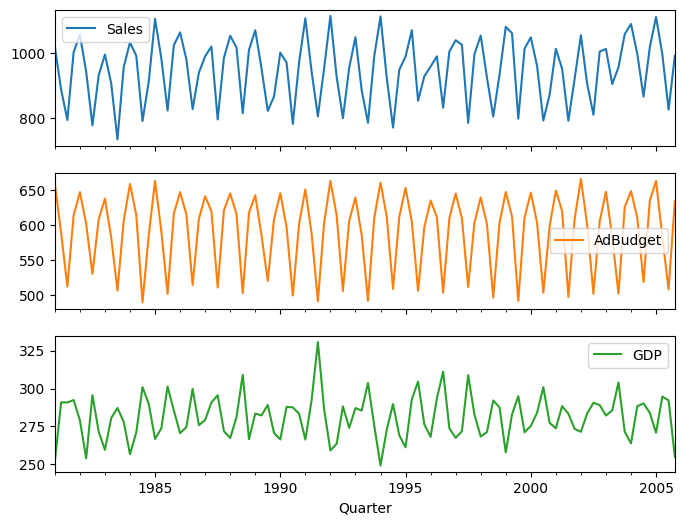

In [65]:
#Question 2.3
tute1 = pd.read_csv('/content/tute1.csv', parse_dates=['Quarter'])
tute1.plot(x='Quarter', y=['Sales', 'AdBudget', 'GDP'], subplots=True, figsize=(8, 6))
plt.show()

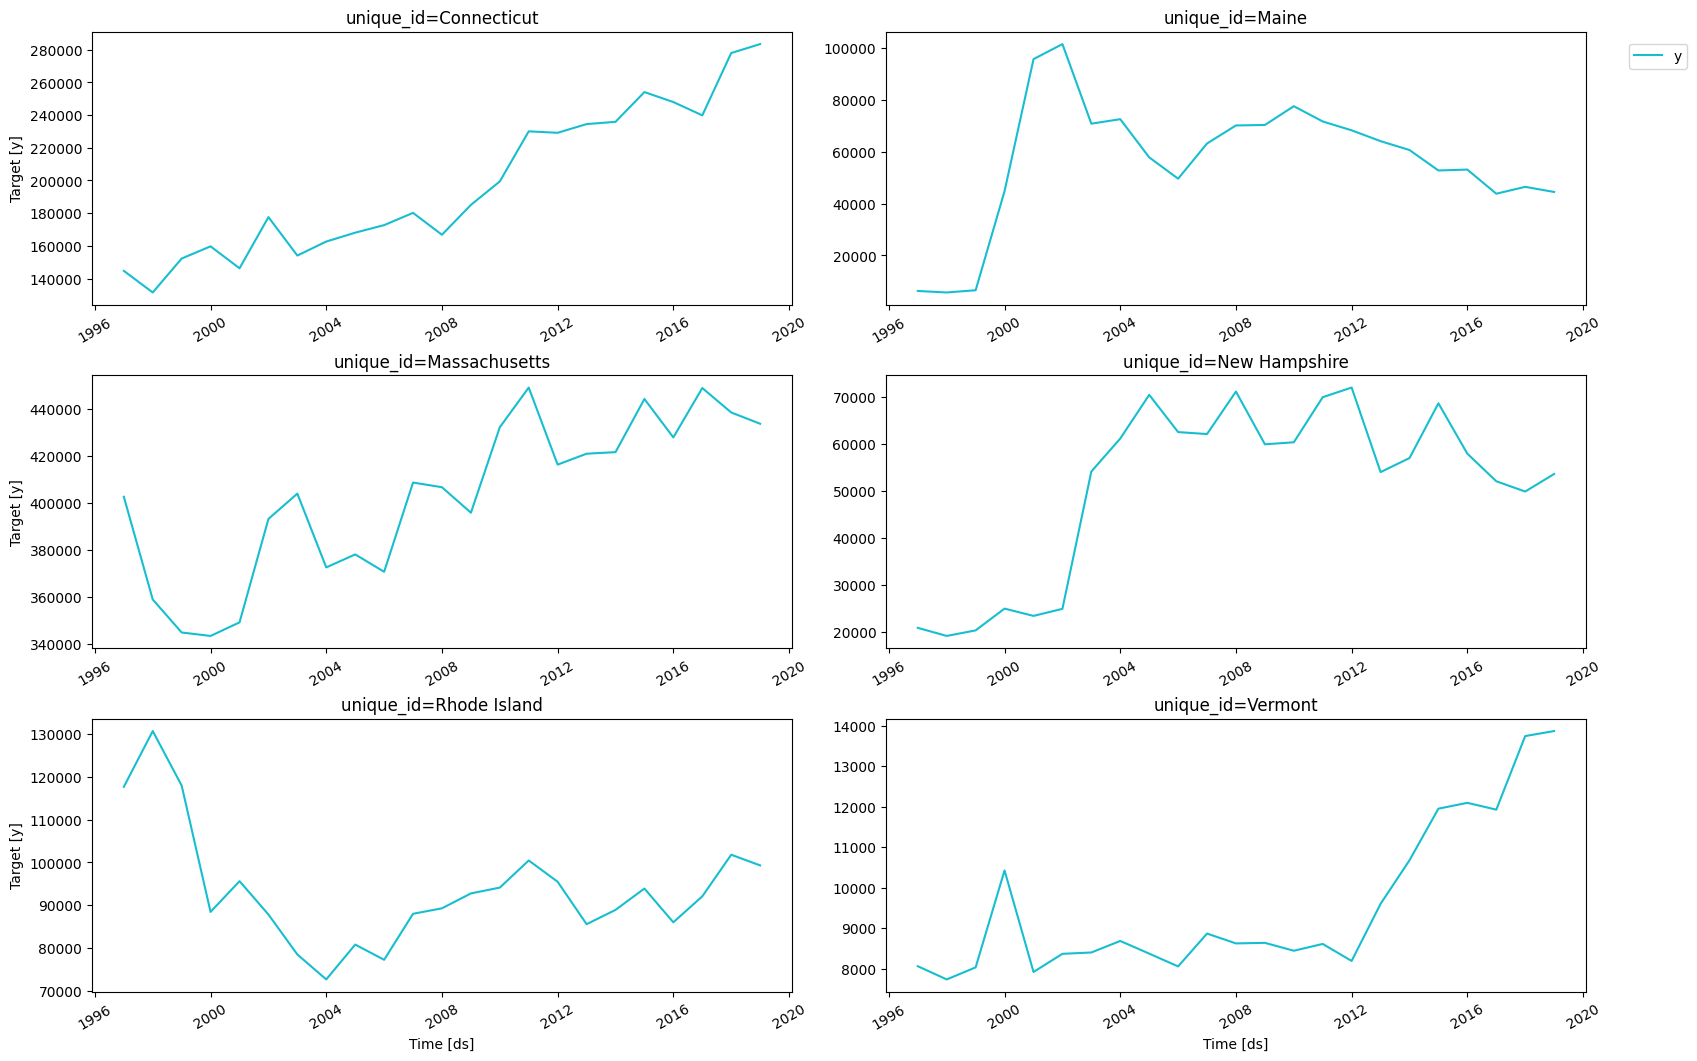

In [66]:
#Question 2.4
us_total = pd.read_csv('/content/us_total.csv', parse_dates=['ds'])

new_england = ["Maine", "Vermont", "New Hampshire",
               "Massachusetts", "Connecticut", "Rhode Island"]

ne_gas = us_total.loc[us_total['unique_id'].isin(new_england)]

plot_series(ne_gas, id_col='unique_id', time_col='ds', target_col='y')

In [69]:
#Question 2.5
tourism = pd.read_csv("/content/tourism.csv")

# 5.3: combination of Region and Purpose with highest average overnight trips
avg_trips = (
    tourism.groupby(["Region", "Purpose"])["y"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_trips.head(1))

# 5.4: total trips by State only
state_totals = (
    tourism.groupby(["State", "ds"], as_index=False)["y"]
    .sum()
)

Region  Purpose 
Sydney  Visiting    747.269968
Name: y, dtype: float64


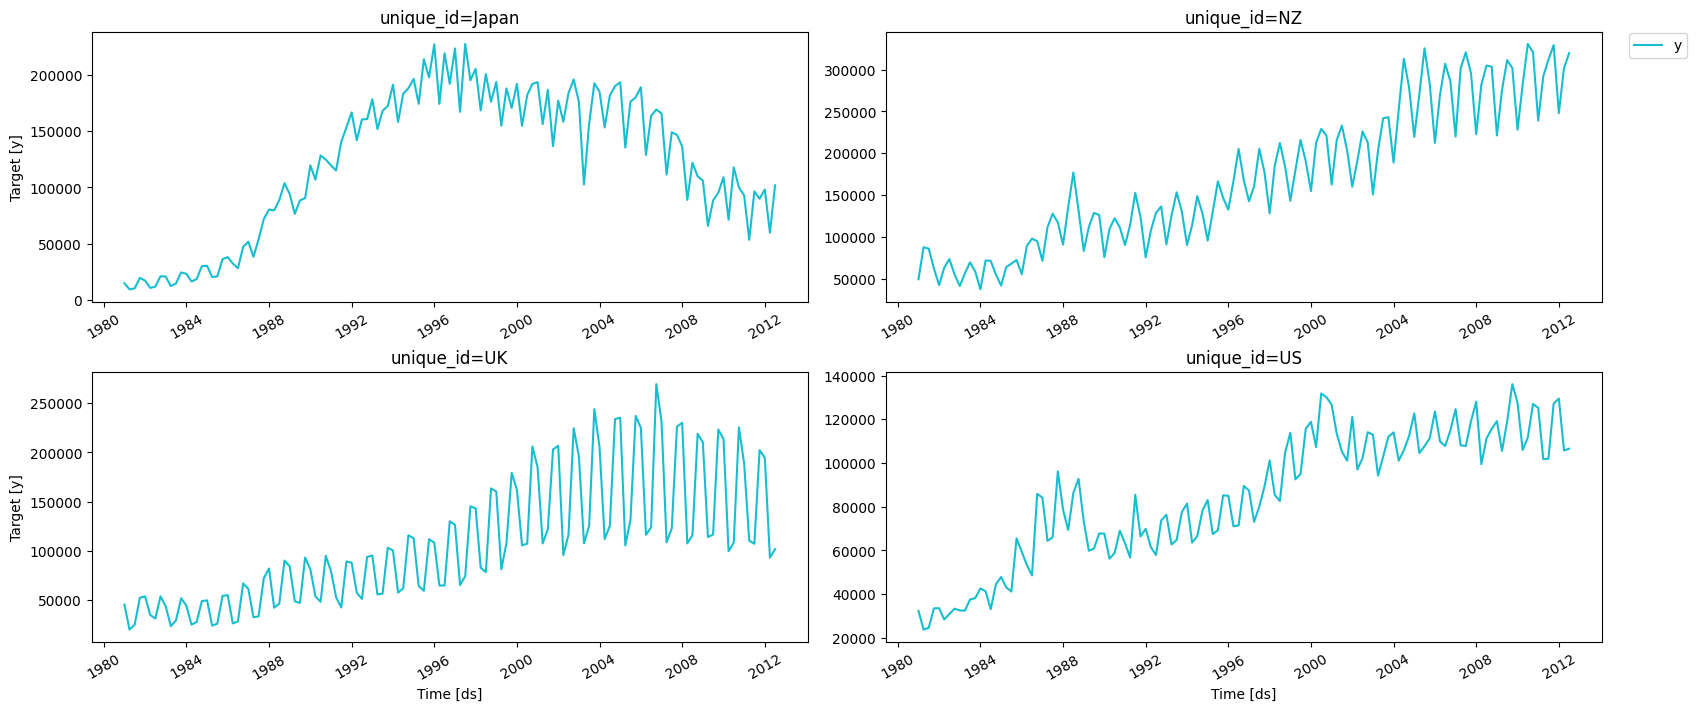

In [74]:
#Question 2.6
aus_arrivals = pd.read_csv('/content/aus_arrivals.csv', parse_dates=['Quarter'])

plot_series(
    aus_arrivals.rename(columns={'Quarter': 'ds', 'Origin': 'unique_id', 'Arrivals': 'y'}),
    id_col='unique_id', time_col='ds', target_col='y'
)

In [92]:
#Question 2.7
aus_retail = pd.read_csv('/content/aus_retail.csv', parse_dates=['Month'])

random = np.random.RandomState(12345678)
random_series_id = random.choice(aus_retail['Series ID'].unique())
myseries = aus_retail.loc[aus_retail['Series ID'] == random_series_id]

print(myseries[['State', 'Industry']].drop_duplicates())

                   State                                  Industry
55712  Western Australia  Cafes, restaurants and catering services


In [109]:
#Question 2.8
series_specs = [
    ("us_employment_formatted.csv", "Total Private", 12),   # monthly
    ("aus_production_formatted.csv", "Bricks", 4),          # quarterly
    ("pelt.csv", "hare", 1),                      # annual — no seasonality to speak of
]

for file, series_id, period in series_specs:
    df = pd.read_csv(f"/content/{file}", parse_dates=["ds"])
    s = df.loc[df["unique_id"] == series_id]
    plot_series(s, id_col="unique_id", time_col="ds", target_col="y")
    if period > 1:
        seasonal_decompose(s.set_index("ds")["y"], period=period).plot()
    lag_plot(s["y"])
    plot_acf(s["y"])

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x0 with 0 Axes>

In [105]:
#Question 2.9
#n/a, couldn't get code for 2.8 to function properly

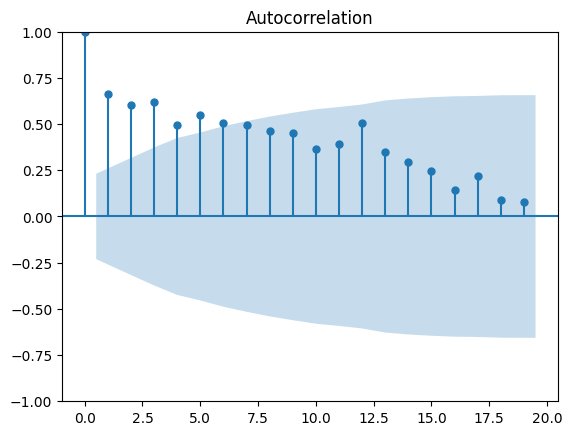

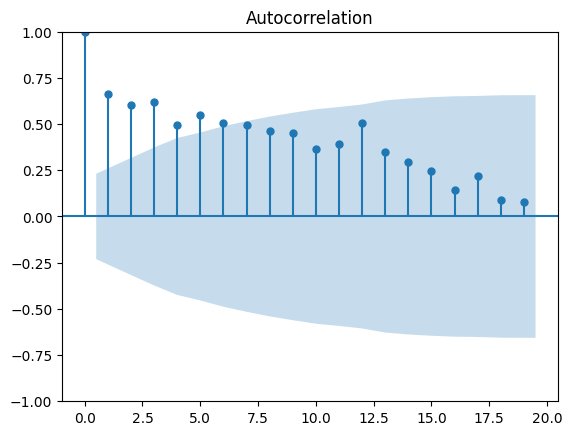

In [108]:
#Question 2.10
aus_livestock = pd.read_csv("/content/aus_livestock.csv", parse_dates=["ds"])

pigs_vic = aus_livestock.loc[
    (aus_livestock["unique_id"] == "Victoria_Pigs")
    & (aus_livestock["ds"] >= "1990")
    & (aus_livestock["ds"] < "1996")
]

plot_series(pigs_vic, id_col="unique_id", time_col="ds", target_col="y")
plot_acf(pigs_vic["y"])

ACF plots above don't look like white noise. Seeing a general trend, no seasonality, but not all points in the confidence band.

In [64]:
## Grading Rubric
- **Correctness (40%)**: Does the code run and produce the expected output?
- **Code Quality (30%)**: Is the code clean, commented, and efficient?
- **Analysis (30%)**: Are the interpretations and explanations clear and accurate?

Object `output` not found.
Object `efficient` not found.
Object `accurate` not found.


In [111]:
# 1. Save the current state of the notebook to the virtual machine
from google.colab import _message
import os

# 2. Get the notebook name automatically and convert it
notebook_name = _message.blocking_request('get_ipynb_file_name', timeout_sec=5)
if notebook_name:
    # Clear characters like spaces if necessary, or pass directly wrapped in quotes
    os.system(f'jupyter nbconvert --to html "{notebook_name}"')
    print(f"Successfully created HTML! Please refresh your sidebar file menu to download it.")
else:
    print("Could not retrieve notebook name. Please use the manual Step-by-Step method above.")


Successfully created HTML! Please refresh your sidebar file menu to download it.
